### Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
from scipy.stats import linregress
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

base_dir = os.getcwd()
parent_dir = os.path.dirname(base_dir)
os.chdir(parent_dir)

np.random.seed(101)

print(f"Current Directory: {os.getcwd()}")

Current Directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study


### Load in expert rating

In [13]:
df = pd.read_csv("data/rawdata/uhn_breast/experiment.csv")

df = df[df["model.type"] == "Parental"]
df = df[df["drug.id"] == "H2O"]
print(df.shape)
df = df[df["volume"] > 0]
print(df.shape)

df_raw_exp = df

(13601, 12)
(13592, 12)


### Set parameters

In [3]:
MAX_DAY = 35      # use first 35 days to estimate exponential growth
MIN_POINTS = 3    # minimum number of time points per mouse
MIN_R2 = 0.8      # minimum fit quality

### Fit log(volume) ~ time for each mouse (model.id)


In [4]:
per_mouse = []

for mouse_id, sub in df.groupby("model.id"):
    sub = sub[sub["time"] <= MAX_DAY].sort_values("time")
    if sub.shape[0] < MIN_POINTS:
        continue

    slope, intercept, r, p, se = linregress(sub["time"], np.log(sub["volume"]))
    r2 = r**2
    if slope <= 0 or r2 < MIN_R2:
        continue

    dt = np.log(2) / slope
    per_mouse.append({
        "mouse_id": mouse_id,
        "modelID": mouse_id.split(".")[0],
        "growth_rate_k": slope,
        "doubling_time_days": dt,
        "r2": r2,
        "n_points": sub.shape[0],
        "max_day_used": sub["time"].max()
    })

per_mouse_df = pd.DataFrame(per_mouse)
print(per_mouse_df.shape)
print(per_mouse_df.head())

per_mouse_df.describe()

(652, 7)
         mouse_id  modelID  growth_rate_k  doubling_time_days        r2  \
0  01-1104.H2O.m1  01-1104       0.079706            8.696311  0.925596   
1  01-1104.H2O.m2  01-1104       0.092724            7.475367  0.996943   
2  01-1104.H2O.m3  01-1104       0.032437           21.369172  0.881759   
3  01-1104.H2O.m4  01-1104       0.030791           22.511444  0.957519   
4  01-1104.H2O.m5  01-1104       0.053893           12.861472  0.987995   

   n_points  max_day_used  
0         6          20.0  
1         4          20.0  
2        11          34.0  
3         5          27.0  
4         5          28.0  


,growth_rate_k,doubling_time_days,r2,n_points,max_day_used
count,652.000000,652.000000,652.000000,652.000000,652.000000
mean,0.059917,15.810961,0.928107,7.253067,28.983129
std,0.038421,9.218823,0.052385,2.671820,6.794415
min,0.009871,2.422609,0.800412,3.000000,6.000000
25%,0.035398,9.643416,0.887349,5.000000,27.000000
50%,0.050449,13.739552,0.941844,6.000000,32.000000
75%,0.071878,19.581374,0.970998,10.000000,34.000000
max,0.286116,70.222959,0.999995,12.000000,35.000000


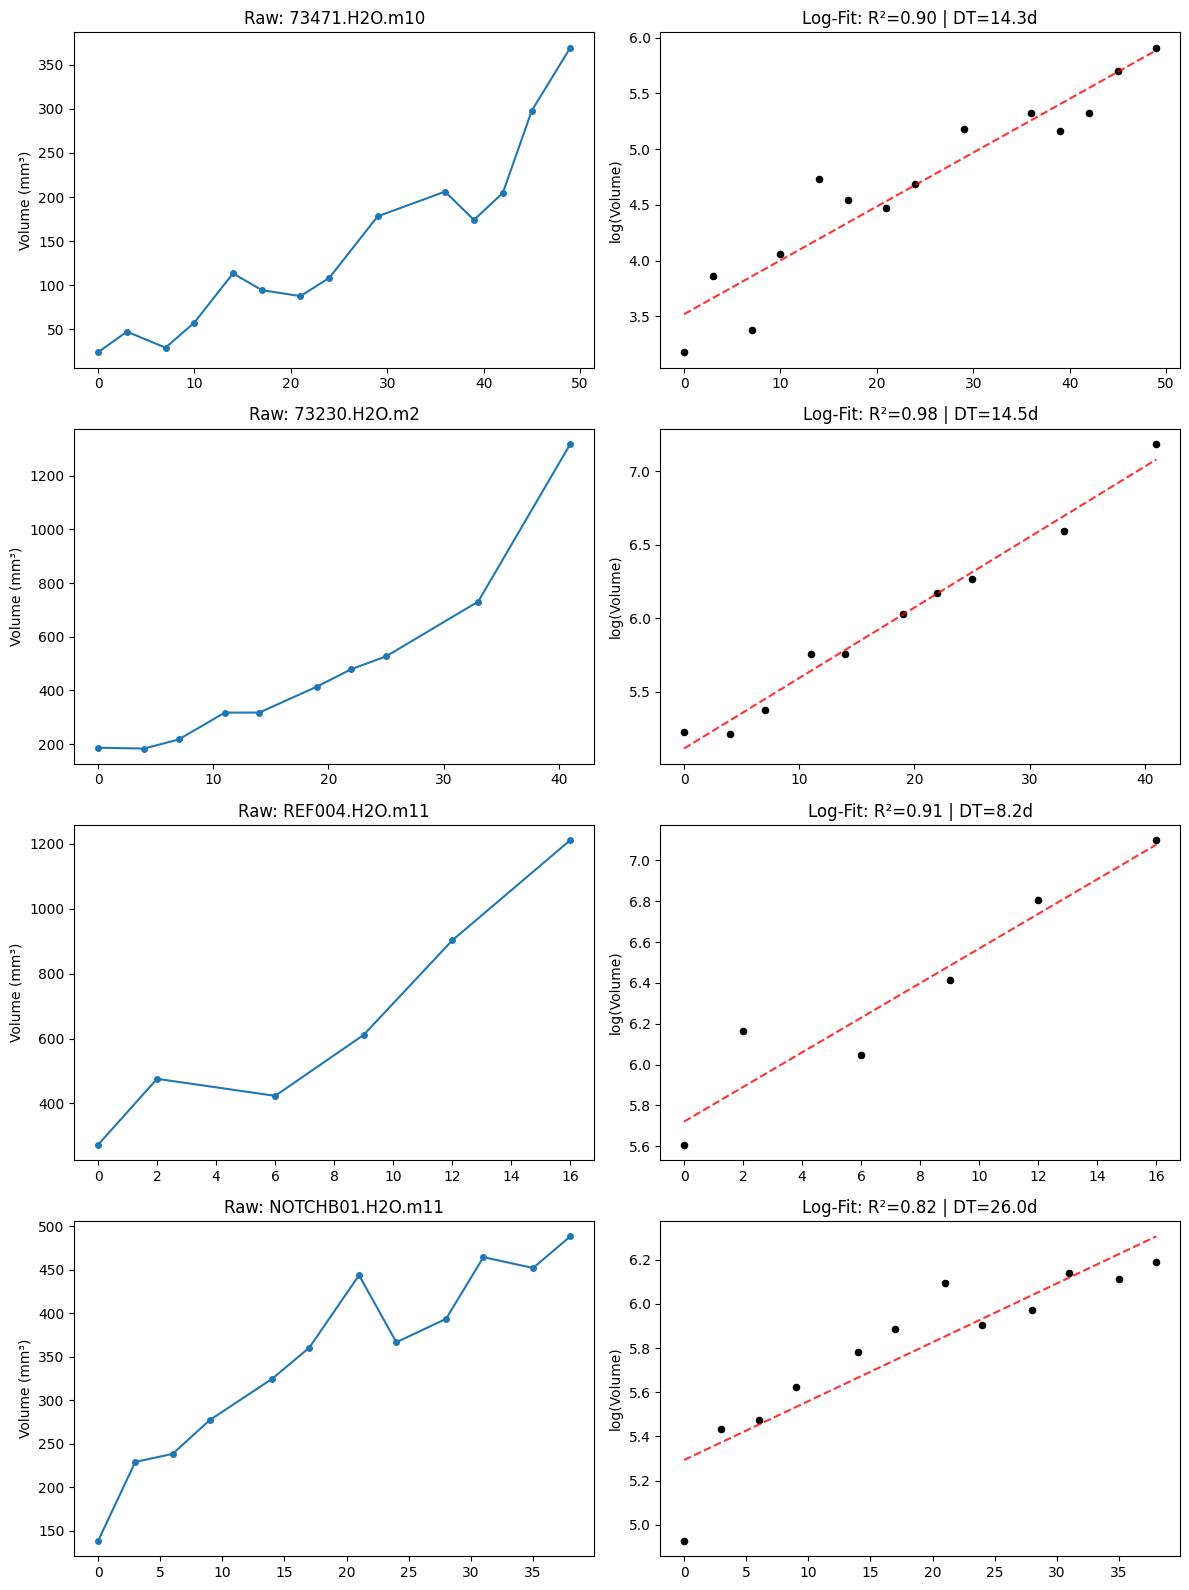

In [5]:
def plot_fit(mouse_id, ax_raw, ax_log):
    # Use 'df' or 'exp' depending on your current variable name
    sub = df[df["model.id"] == mouse_id].sort_values("time")
    if sub.empty: return

    # Raw Volume Plot
    ax_raw.plot(sub["time"], sub["volume"], 'o-', color="tab:blue", markersize=4)
    ax_raw.set_title(f"Raw: {mouse_id}")
    ax_raw.set_ylabel("Volume (mm³)")

    # Log-Linear Plot
    x = sub["time"]
    y = np.log(sub["volume"])
    slope, intercept, r, p, se = linregress(x, y)
    
    ax_log.scatter(x, y, color="black", s=20)
    ax_log.plot(x, intercept + slope * x, 'r--', alpha=0.8)
    
    dt_val = np.log(2)/slope if slope > 0 else 0
    ax_log.set_title(f"Log-Fit: R²={r**2:.2f} | DT={dt_val:.1f}d")
    ax_log.set_ylabel("log(Volume)")

# 1. Pick 4 random mouse IDs from your processed data
example_ids = np.random.choice(per_mouse_df["mouse_id"], size=4, replace=False)

# 2. Create a 4x2 grid (4 mice, each with a Raw and Log plot)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))

for i, mouse in enumerate(example_ids):
    plot_fit(mouse, axes[i, 0], axes[i, 1])

plt.tight_layout()
plt.show()

### Aggregate to model level

In [6]:
per_model_df = (
    per_mouse_df.groupby("modelID")
    .agg(
        # 1. Median Doubling Time (Robust to outliers)
        median_doubling_time=("doubling_time_days", "median"),
        
        # 2. Mean of Growth Rates (Statistically stable)
        avg_growth_rate_k=("growth_rate_k", "mean"),
        
        # 3. Standard deviation for error bars
        sd_doubling_time=("doubling_time_days", "std"),
        
        n_mice=("mouse_id", "nunique"),

        mean_r2=("r2", "mean")
    )
    .reset_index()
)

# Calculate a "Global" doubling time from the average growth rate
per_model_df["global_doubling_time"] = np.log(2) / per_model_df["avg_growth_rate_k"]

In [7]:
# correct certain model ids if needd
per_model_df["modelID"] = per_model_df["modelID"].str.replace(r"REF_[A-Z]_", "REF", regex=True)
per_model_df["modelID"] = per_model_df["modelID"].str.replace(r"REF_", "REF", regex=True)
per_model_df["modelID"] = per_model_df["modelID"].str.replace("_009_BL", "009", regex=False)
per_model_df["modelID"] = per_model_df["modelID"].str.replace("REFS036", "REF036", regex=False)

# 1. Sort by modelID (alphabetical) and n_mice (descending)
per_model_df = per_model_df.sort_values(
    by=["modelID", "n_mice"], 
    ascending=[True, False]
)

# 2. Drop duplicates, keeping the first (which now has the highest n_mice)
per_model_df = per_model_df.drop_duplicates(subset="modelID", keep="first")

filter_pattern = r"_|^SA|RES"
per_model_df = per_model_df[~per_model_df["modelID"].str.contains(filter_pattern, regex=True)]

mask = per_model_df["modelID"].str.match(r'^\d', na=False)
per_model_df.loc[mask, "modelID"] = "S" + per_model_df.loc[mask, "modelID"]

# 3. Reset index for a clean dataframe
per_model_df = per_model_df.reset_index(drop=True)

print(per_model_df.shape)
print(per_model_df.head())

per_model_df.describe()

per_model_df.to_csv("data/procdata/1_doublingRate/model_doubling_times.csv", index=False)

(95, 7)
    modelID  median_doubling_time  avg_growth_rate_k  sd_doubling_time  \
0  S01-1104             13.754697           0.054394          5.379004   
1   S100534             17.530165           0.035535          7.107508   
2   S100672             31.284827           0.023827          6.928591   
3   S100804             32.209237           0.021520          0.085138   
4   S104987             12.368974           0.056039               NaN   

   n_mice   mean_r2  global_doubling_time  
0       8  0.925560             12.743107  
1       4  0.923210             19.506279  
2       3  0.880525             29.091263  
3       2  0.904246             32.209124  
4       1  0.993418             12.368974  


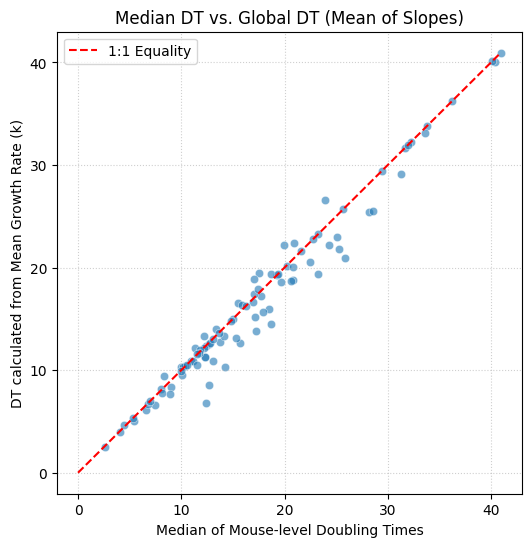

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))

# 1. Scatter plot
sns.scatterplot(
    data=per_model_df, 
    x="median_doubling_time", 
    y="global_doubling_time", 
    alpha=0.6
)

# 2. Add a 1:1 identity line for reference
max_val = max(per_model_df["median_doubling_time"].max(), per_model_df["global_doubling_time"].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label="1:1 Equality")

plt.title("Median DT vs. Global DT (Mean of Slopes)")
plt.xlabel("Median of Mouse-level Doubling Times")
plt.ylabel("DT calculated from Mean Growth Rate (k)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

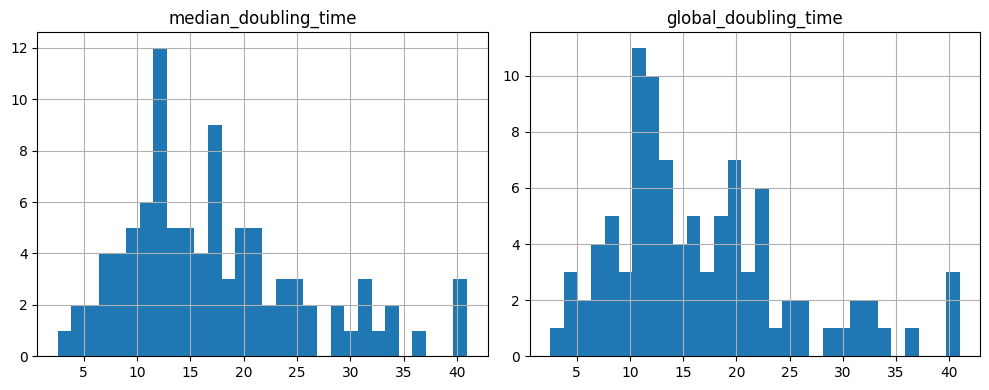

In [9]:
per_model_df[["median_doubling_time", "global_doubling_time"]].hist(bins=30, figsize=(10, 4))
plt.tight_layout()

In [10]:
qc_summary = pd.Series({
    "Total models": len(per_model_df),
    "Models with ≥2 replicates": (per_model_df["n_mice"] >= 2).sum(),
    "Median DT (days)": round(per_model_df["median_doubling_time"].median(), 2),
    "Mean DT (days)": round(per_model_df["median_doubling_time"].mean(), 2),
    "Fast models (DT < 10d)": (per_model_df["median_doubling_time"] < 10).sum(),
    "Slow models (DT > 40d)": (per_model_df["median_doubling_time"] > 40).sum(),
    "Mean R²": round(per_model_df["mean_r2"].mean(), 3),
})

print(qc_summary)

Total models                 95.000
Models with ≥2 replicates    72.000
Median DT (days)             15.640
Mean DT (days)               17.310
Fast models (DT < 10d)       16.000
Slow models (DT > 40d)        3.000
Mean R²                       0.924
dtype: float64


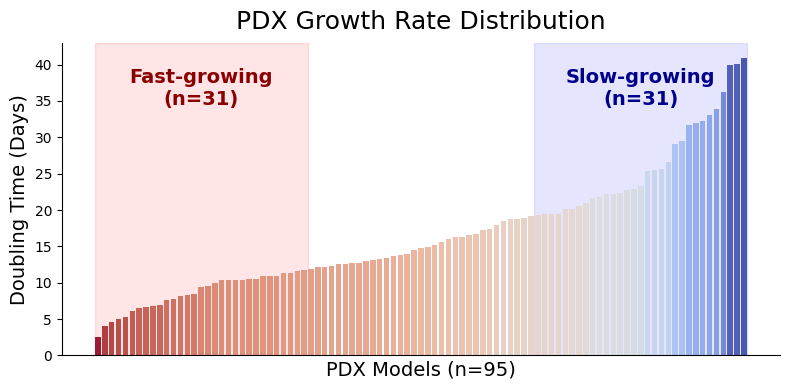

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

per_model_df = per_model_df.sort_values("global_doubling_time").reset_index(drop=True)

norm = mcolors.Normalize(vmin=per_model_df["global_doubling_time"].min(), 
                         vmax=per_model_df["global_doubling_time"].max())
cmap = plt.get_cmap("coolwarm_r")
custom_colors = [cmap(norm(v)) for v in per_model_df["global_doubling_time"]]

fig, ax = plt.subplots(figsize=(8, 4))

# Plot bars
sns.barplot(x="modelID", y="global_doubling_time", data=per_model_df, palette=custom_colors, ax=ax)

# 1. REMOVE X-AXIS TICK LABELS (Model Names)
ax.set_xticklabels([]) 
ax.set_xticks([]) # Removes the tick marks entirely for a cleaner baseline

# Calculate indices for shading (1/3 of 81 = 27)
n_models = len(per_model_df)
one_third = n_models // 3

# 1. Shade Fast-growing models (Left side / Red-ish zone)
ax.axvspan(-0.5, one_third - 0.5, color='red', alpha=0.1, zorder=0)
ax.text(one_third/2 - 0.5, ax.get_ylim()[1]*0.8, f"Fast-growing\n(n={one_third})", 
        color='darkred', weight='bold', ha='center', fontsize=14)

# 2. Shade Slow-growing models (Right side / Blue-ish zone)
ax.axvspan(n_models - one_third - 0.5, n_models - 0.5, color='blue', alpha=0.1, zorder=0)
ax.text(n_models - one_third/2 - 0.5, ax.get_ylim()[1]*0.8, f"Slow-growing\n(n={one_third})", 
        color='darkblue', weight='bold', ha='center', fontsize=14)

# Styling
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
# Short & Clean Labels
ax.set_title("PDX Growth Rate Distribution", fontsize=18, pad=10)
ax.set_ylabel("Doubling Time (Days)", fontsize=14)
ax.set_xlabel(f"PDX Models (n={n_models})", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("data/procdata/1_doublingRate/DT_sorted.png", dpi=300, bbox_inches="tight")
plt.show()

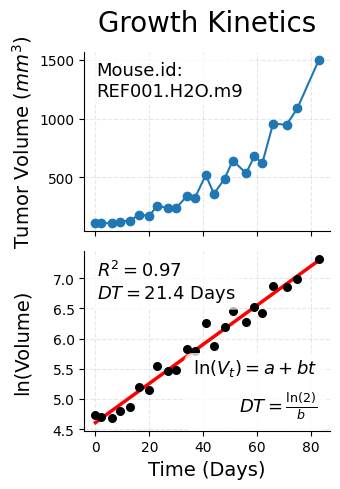

In [19]:
target_mouse = "REF001.H2O.m9"

# Load and filter
sub = df_raw_exp[df_raw_exp["model.id"] == target_mouse].sort_values("time")
sub = sub[sub["volume"] > 0] # Ensure no log(0) errors

# === Calculations ===
x = sub["time"]
y = np.log(sub["volume"])
slope, intercept, r_val, p_val, std_err = linregress(x, y)

y_pred = intercept + slope * x
r2 = r_val**2
dt_days = np.log(2) / slope if slope > 0 else np.nan

# === Plotting (Vertical Layout) ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.5, 5), sharex=True)

# 1. Top Panel: Raw Volume
ax1.plot(sub["time"], sub["volume"], marker='o', color='tab:blue', markersize=6, linewidth=1.5)
ax1.set_ylabel("Tumor Volume ($mm^3$)", fontsize=14)
ax1.set_title("Growth Kinetics", fontsize=20, pad=15)
#ax1.set_title(f"{target_mouse}", fontsize=20, pad=15)
ax1.grid(True, linestyle='--', alpha=0.3)

results_text = f"Mouse.id:\n{target_mouse}"
ax1.text(0.05, 0.95, results_text, transform=ax1.transAxes, 
         fontsize=13, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# 2. Bottom Panel: Log-Linear Fit
ax2.scatter(x, y, color="black", s=30, zorder=3)
ax2.plot(x, y_pred, color="red", lw=2.5, zorder=2)
ax2.set_xlabel("Time (Days)", fontsize=14)
ax2.set_ylabel("ln(Volume)", fontsize=14, labelpad=15)
ax2.grid(True, linestyle='--', alpha=0.3)

# --- SPLIT ANNOTATION ---

# A. SPECIFIC RESULTS (Top Left)
results_text = f"$R^2 = {r2:.2f}$\n$DT = {dt_days:.1f}$ Days"
ax2.text(0.05, 0.95, results_text, transform=ax2.transAxes, 
         fontsize=13, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# B. THE GENERAL FORMULA (Bottom Right)
# We use a slightly smaller font or italic style to show it's the "definition"
# Use an 'rf' string (raw + f-string) for the best results
# Use 'rf' for a Raw F-string to handle both LaTeX backslashes and variables
formula_text = (
    rf"$\ln(V_t) = a + bt$" + "\n"
    rf"$DT = \frac{{\ln(2)}}{{b}}$"
)

# Placement in the lower right
ax2.text(0.95, 0.05, formula_text, transform=ax2.transAxes, 
         fontsize=13, verticalalignment='bottom', horizontalalignment='right',
         linespacing=1.6, # Adds a bit of breathing room between the two lines
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='none'))

# Aesthetic Cleanup
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# === Save ===
plt.savefig("results/1_doublingRate/figure2b_growth_kinetics.png", dpi=300, bbox_inches="tight")
#plt.savefig("data/procdata/1_doublingRate/DT_calculation_vertical.pdf", bbox_inches="tight")
plt.show()